<a href="https://colab.research.google.com/github/rishabh7302/Pytorch/blob/main/ANN_fashion_mnist_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [28]:
#set random seed for reproducibility
torch.manual_seed(42)

In [29]:
df=pd.read_csv("fmnist_small.csv")
df.sample(5)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
5469,0,0,0,0,1,0,3,0,0,0,...,135,141,107,0,0,0,0,0,0,0
1825,4,0,0,0,0,0,0,0,0,0,...,18,0,0,0,0,0,0,0,0,0
5468,3,0,0,0,0,0,0,0,0,0,...,55,0,0,0,0,0,0,0,0,0
4396,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2444,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
df.shape

(6000, 785)

In [31]:
df["label"].unique()

array([9, 7, 0, 8, 1, 4, 2, 6, 5, 3])

In [32]:
type(df.iloc[0,1:])

pandas.core.series.Series

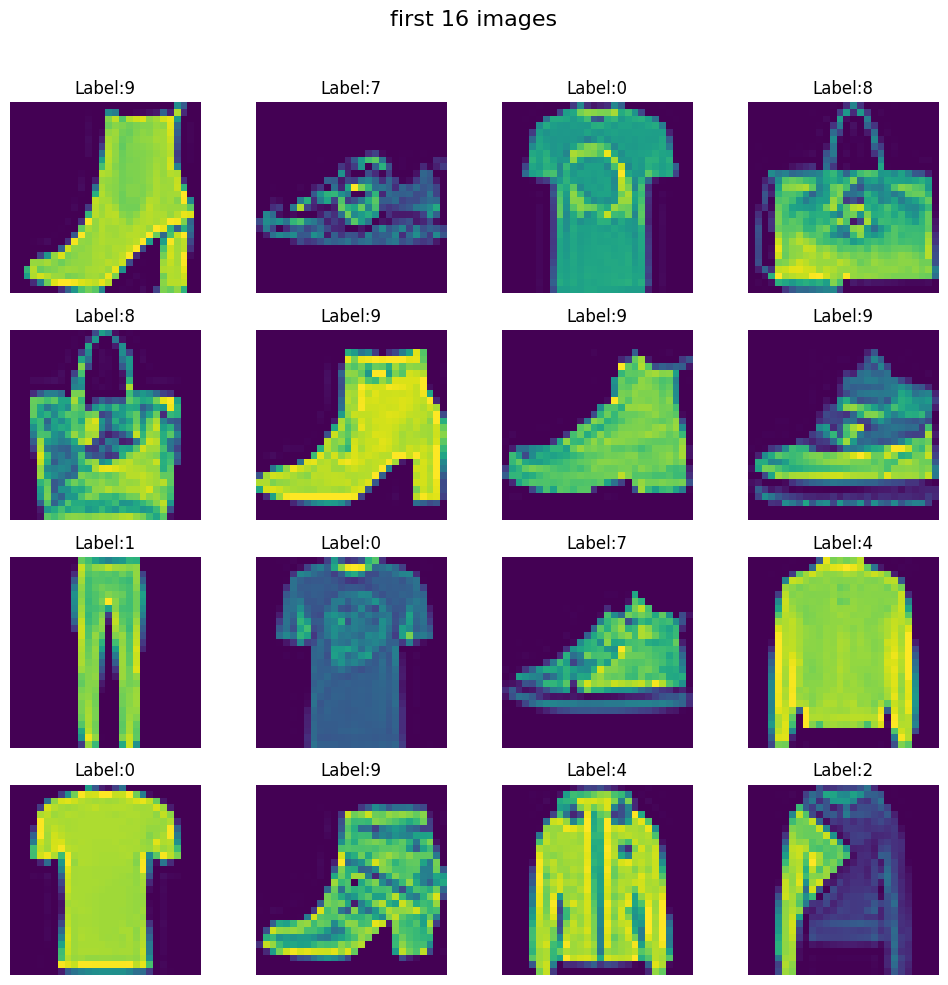

In [33]:
# create a 4 x 4 grid of images
fig,axes=plt.subplots(4,4,figsize=(10,10))
fig.suptitle("first 16 images",fontsize=16)

# plot the first 16 images from the dataset

for i ,ax in enumerate(axes.flat):
  img=df.iloc[i,1:].values.reshape(28,28) # reshape to 28 X 28
  ax.imshow(img)
  ax.axis("off")
  ax.set_title(f"Label:{df.iloc[i,0]}") # show the label
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [34]:
x=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [35]:
x

array([[  0,   0,   0, ..., 165,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]])

In [36]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [37]:
#scaling the features
x_train=x_train/255
x_test=x_test/255

In [38]:
x_train

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.0627451, 0.       ,
        0.       ]])

In [39]:
# create custom dataset
from torch.utils.data import Dataset,DataLoader
class CustomDataset(Dataset):

  def __init__(self,features,labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features);

  def __getitem__(self,index):
    return self.features[index],self.labels[index]


In [40]:
# create train dataset object
train_dataset=CustomDataset(x_train,y_train)
test_dataset=CustomDataset(x_test,y_test)

In [41]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [42]:
# create train and test loader

train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=True)


In [43]:
# define NN class
import torch.nn as nn
class MyNN(nn.Module):

  def __init__(self,num_features):
    super().__init__()

    self.model=nn.Sequential(nn.Linear(num_features,128),nn.ReLU(),nn.Linear(128,64),nn.ReLU(),nn.Linear(64,10))

  def forward(self,x):
    return self.model(x)


In [44]:
# learning rate and epochs
epochs=100
learning_rate=0.1

In [45]:
import torch.optim as optim
# instantiate the model
model=MyNN(x_train.shape[1])

# loss function
criterion=nn.CrossEntropyLoss()

# optimizer
optimizer=optim.SGD(model.parameters(),lr=learning_rate)


In [46]:
len(train_loader)

150

In [47]:
# training loop
for epoch in range(epochs):
  total_epoch_loss=0
  for batch_features,batch_labels in train_loader:
    # forward pass
    output=model(batch_features)

    # loss calculate
    loss=criterion(output,batch_labels)

    # backward pass

    optimizer.zero_grad()
    loss.backward()

    # update grad

    optimizer.step()

    total_epoch_loss+=loss.item()

  avg_loss=total_epoch_loss/len(train_loader)
  print(f"Epoch:{epoch+1}----Avg_Loss:{avg_loss}")







Epoch:1----Avg_Loss:1.3216368528207143
Epoch:2----Avg_Loss:0.7793365389108657
Epoch:3----Avg_Loss:0.6427524648110072
Epoch:4----Avg_Loss:0.5751657428344091
Epoch:5----Avg_Loss:0.5281802035371462
Epoch:6----Avg_Loss:0.49528750280539197
Epoch:7----Avg_Loss:0.4602432996034622
Epoch:8----Avg_Loss:0.435945917169253
Epoch:9----Avg_Loss:0.41829213748375577
Epoch:10----Avg_Loss:0.39840924287835755
Epoch:11----Avg_Loss:0.3850264524420102
Epoch:12----Avg_Loss:0.37226856033007305
Epoch:13----Avg_Loss:0.34775472511847816
Epoch:14----Avg_Loss:0.34747447177767754
Epoch:15----Avg_Loss:0.31615055337548253
Epoch:16----Avg_Loss:0.31182024608055753
Epoch:17----Avg_Loss:0.2919234921534856
Epoch:18----Avg_Loss:0.2852401979267597
Epoch:19----Avg_Loss:0.2716610049704711
Epoch:20----Avg_Loss:0.2620930323501428
Epoch:21----Avg_Loss:0.2573009904225667
Epoch:22----Avg_Loss:0.2422846657037735
Epoch:23----Avg_Loss:0.2393271365016699
Epoch:24----Avg_Loss:0.22775985998411974
Epoch:25----Avg_Loss:0.224474375123779
Ep

In [48]:
# set_model to evaluation mode

model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [51]:
total=0
correct=0

with torch.no_grad():
  for batch_features,batch_labels in test_loader:
    output=model(batch_features)
    _,predictions = torch.max(output,1)

    total+=batch_features.shape[0]
    correct += (predictions==batch_labels).sum().item()
  print(f"Accuracy:{(correct/total)*100}")

Accuracy:82.91666666666667
